In [1]:
import seaborn as sns

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [2]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
print("Mean fare:", df['fare'].mean())
print("Median fare:", df['fare'].median())

Mean fare: 32.204207968574636
Median fare: 14.4542


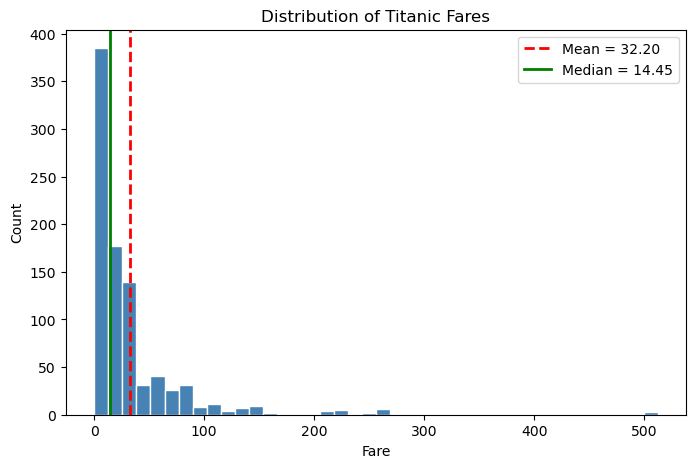

In [9]:
import matplotlib.pyplot as plt

mean_fare = df['fare'].mean()
median_fare = df['fare'].median()

plt.figure(figsize=(8, 5))
plt.hist(df['fare'], bins=40, color='steelblue', edgecolor='white')
plt.axvline(mean_fare, color='red', linestyle='--', linewidth=2,
            label=f'Mean = {mean_fare:.2f}')
plt.axvline(median_fare, color='green', linestyle='-', linewidth=2,
            label=f'Median = {median_fare:.2f}')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.title('Distribution of Titanic Fares')
plt.legend()
plt.show()

In [11]:
import numpy as np

data = np.array([2, 10, 8, 6, 3, 7])

mean = data.mean()
deviations = data - mean
squared = deviations ** 2
variance = squared.mean()
std = np.sqrt(variance)

print("Data:        ", data)
print("Mean:        ", mean)
print("Deviations:  ", deviations)
print("Squared:     ", squared)
print("Variance:    ", variance, "(mean of squared deviations)")
print("Std dev:     ", std, "(square root of variance)")

# Verify against numpy's built-in
print("\n np.std check:", np.std(data))
print("\n pd.std check:", np.std(data))

Data:         [ 2 10  8  6  3  7]
Mean:         6.0
Deviations:   [-4.  4.  2.  0. -3.  1.]
Squared:      [16. 16.  4.  0.  9.  1.]
Variance:     7.666666666666667 (mean of squared deviations)
Std dev:      2.7688746209726918 (square root of variance)

np.std check: 2.7688746209726918


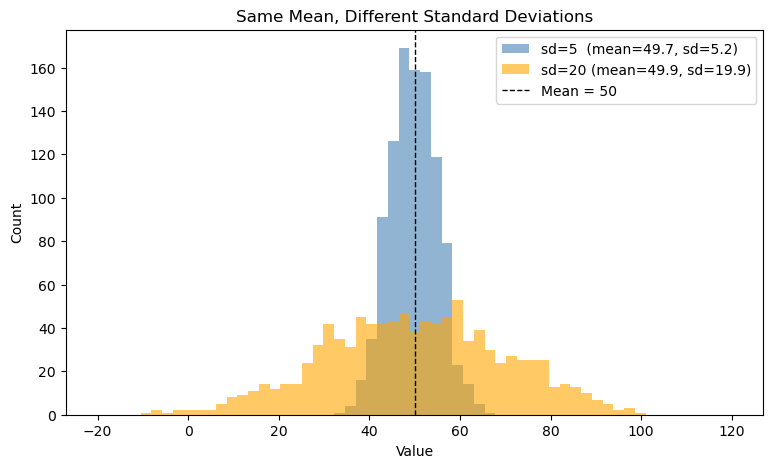

In [14]:
rng = np.random.default_rng(101)

sample_narrow = rng.normal(loc=50, scale=5, size=1000)
sample_wide = rng.normal(loc=50, scale=20, size=1000)

plt.figure(figsize=(9, 5))
bins = np.linspace(-20, 120, 60)
plt.hist(sample_narrow, bins=bins, alpha=0.6, color='steelblue',
         label=f'sd=5  (mean={sample_narrow.mean():.1f}, sd={sample_narrow.std():.1f})')
plt.hist(sample_wide, bins=bins, alpha=0.6, color='orange',
         label=f'sd=20 (mean={sample_wide.mean():.1f}, sd={sample_wide.std():.1f})')
plt.axvline(50, color='black', linestyle='--', linewidth=1, label='Mean = 50')
plt.xlabel('Value')
plt.ylabel('Count')
plt.title('Same Mean, Different Standard Deviations')
plt.legend()
plt.show()

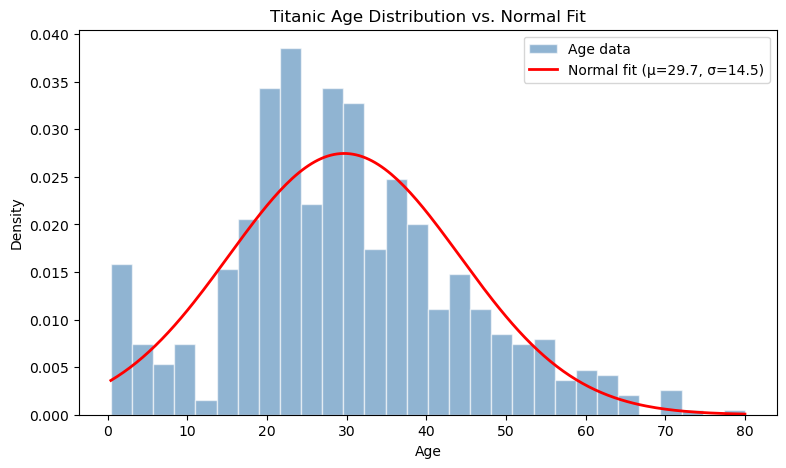

In [15]:
from scipy import stats

age = df['age'].dropna()
mu, sigma = age.mean(), age.std()

plt.figure(figsize=(9, 5))
plt.hist(age, bins=30, density=True, alpha=0.6, color='steelblue',
         edgecolor='white', label='Age data')

x = np.linspace(age.min(), age.max(), 200)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2,
         label=f'Normal fit (μ={mu:.1f}, σ={sigma:.1f})')

plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Titanic Age Distribution vs. Normal Fit')
plt.legend()
plt.show()

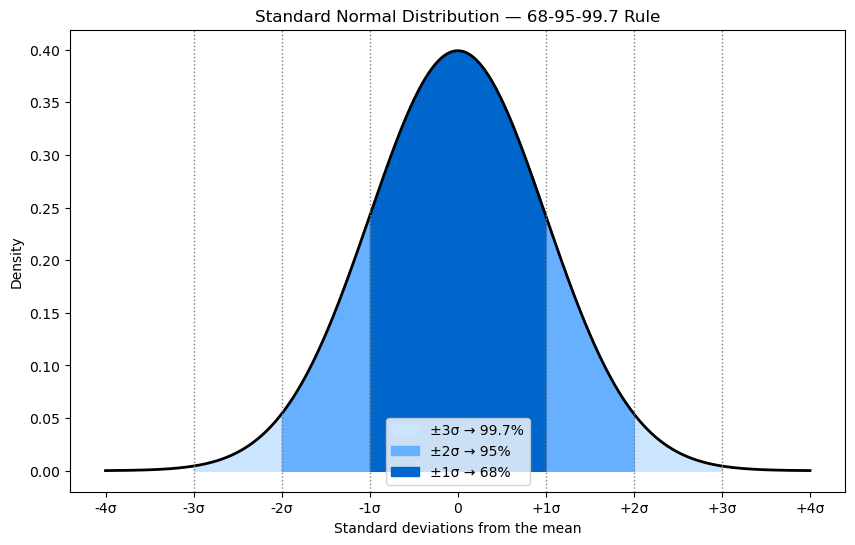

In [25]:
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)

# Shade nested regions: ±3 (lightest) under ±2 under ±1 (darkest)
plt.fill_between(x, y, where=(np.abs(x) <= 3), color='#cce5ff',
                 label='±3σ → 99.7%')
plt.fill_between(x, y, where=(np.abs(x) <= 2), color='#66b0ff',
                 label='±2σ → 95%')
plt.fill_between(x, y, where=(np.abs(x) <= 1), color='#0066cc',
                 label='±1σ → 68%')

# Mark the sigma boundaries
for k in [-3, -2, -1, 1, 2, 3]:
    plt.axvline(k, color='gray', linestyle=':', linewidth=1)

plt.xticks(range(-4, 5),
           ['-4σ', '-3σ', '-2σ', '-1σ', '0', '+1σ', '+2σ', '+3σ', '+4σ'])
plt.xlabel('Standard deviations from the mean')
plt.ylabel('Density')
plt.title('Standard Normal Distribution — 68-95-99.7 Rule')
plt.legend()
plt.show()

In [26]:
age = df['age'].dropna()

stat, p = stats.shapiro(age)
print(f"Shapiro-Wilk statistic: {stat:.4f}")
print(f"p-value:                {p:.2e}")

alpha = 0.05
if p < alpha:
    print(f"\np < {alpha}: reject H0 — age is NOT normally distributed.")
else:
    print(f"\np >= {alpha}: fail to reject H0 — age looks normal.")

Shapiro-Wilk statistic: 0.9815
p-value:                7.34e-08

p < 0.05: reject H0 — age is NOT normally distributed.


In [27]:
df['fare_zscore'] = (df['fare'] - df['fare'].mean()) / df['fare'].std()

outliers = df[df['fare_zscore'].abs() > 3]
print(f"Rows with |z| > 3: {len(outliers)}")
outliers[['pclass', 'sex', 'age', 'fare', 'fare_zscore']].sort_values('fare_zscore', ascending=False)

Rows with |z| > 3: 20


,pclass,sex,age,fare,fare_zscore
258,1,female,35.0,512.3292,9.661740
679,1,male,36.0,512.3292,9.661740
737,1,male,35.0,512.3292,9.661740
27,1,male,19.0,263.0000,4.644393
341,1,female,24.0,263.0000,4.644393
438,1,male,64.0,263.0000,4.644393
88,1,female,23.0,263.0000,4.644393
311,1,female,18.0,262.3750,4.631815
742,1,female,21.0,262.3750,4.631815
118,1,male,24.0,247.5208,4.332899


In [38]:
iq_mean, iq_std = 100, 15
iq = 140

z = (iq - iq_mean) / iq_std
percentile = stats.norm.cdf(z) * 100

print(f"z-score:     {z:.4f}")
print(f"Percentile:  {percentile:.2f}%")
print(f"\nAn IQ of {iq} is {z:.2f} standard deviations above the mean,")
print(f"higher than ~{percentile:.2f}% of the population.")

z-score:     2.6667
Percentile:  99.62%

An IQ of 140 is 2.67 standard deviations above the mean,
higher than ~99.62% of the population.


In [42]:
pg = sns.load_dataset('penguins').dropna()
print(f"Shape after dropna: {pg.shape}")
pg.head()

Shape after dropna: (333, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


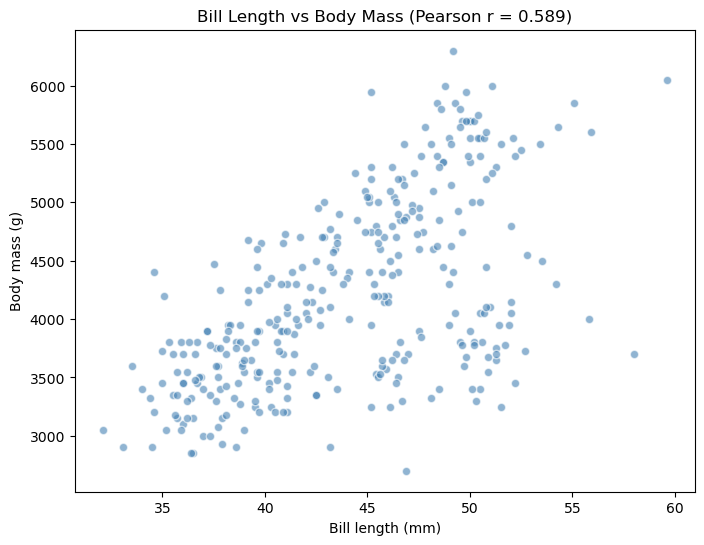

Pearson correlation coefficient: 0.5895
p-value:                         1.54e-32


In [43]:
r, p = stats.pearsonr(pg['bill_length_mm'], pg['body_mass_g'])

plt.figure(figsize=(8, 6))
plt.scatter(pg['bill_length_mm'], pg['body_mass_g'],
            alpha=0.6, color='steelblue', edgecolor='white')
plt.xlabel('Bill length (mm)')
plt.ylabel('Body mass (g)')
plt.title(f'Bill Length vs Body Mass (Pearson r = {r:.3f})')
plt.show()

print(f"Pearson correlation coefficient: {r:.4f}")
print(f"p-value:                         {p:.2e}")

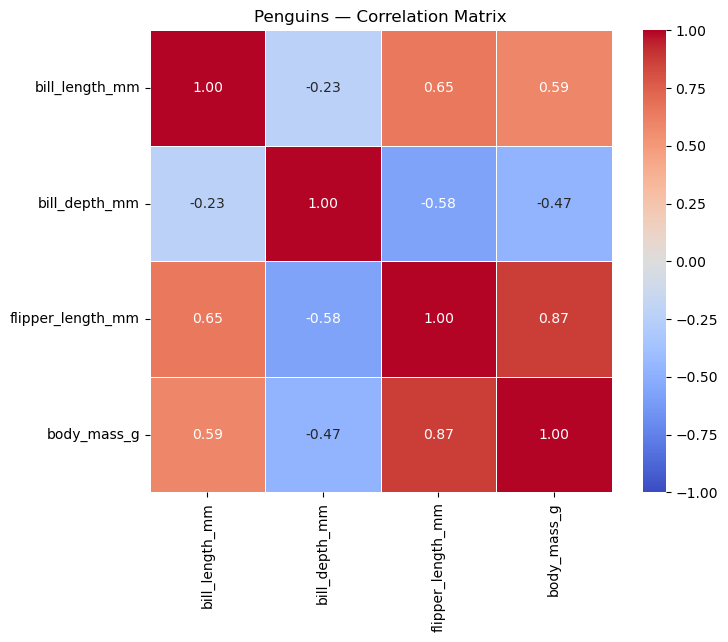

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


In [45]:
corr = pg.select_dtypes('number').corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Penguins — Correlation Matrix')
plt.show()

corr

In [52]:
overall_r = pg['body_mass_g'].corr(pg['bill_depth_mm'])

by_species = (
    pg.groupby('species')
      .apply(lambda g: g['body_mass_g'].corr(g['bill_depth_mm']))
      .rename('corr(body_mass, bill_depth)')
      .to_frame()
)

print(f"Overall (pooled) correlation: {overall_r:.3f}\n")
print("Within each species:")
by_species

Overall (pooled) correlation: -0.472

Within each species:


,"corr(body_mass, bill_depth)"
species,
Adelie,0.580156
Chinstrap,0.604498
Gentoo,0.722967


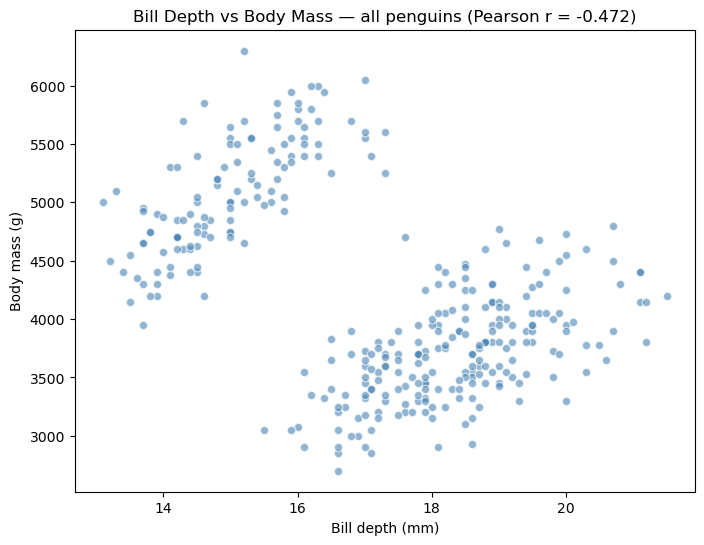

Overall Pearson correlation: -0.4720
p-value:                     7.02e-20


In [53]:
r, p = stats.pearsonr(pg['bill_depth_mm'], pg['body_mass_g'])

plt.figure(figsize=(8, 6))
plt.scatter(pg['bill_depth_mm'], pg['body_mass_g'],
            alpha=0.6, color='steelblue', edgecolor='white')
plt.xlabel('Bill depth (mm)')
plt.ylabel('Body mass (g)')
plt.title(f'Bill Depth vs Body Mass — all penguins (Pearson r = {r:.3f})')
plt.show()

print(f"Overall Pearson correlation: {r:.4f}")
print(f"p-value:                     {p:.2e}")

In [54]:
overall_mean = df['fare'].mean()

first_class_survivors = df[(df['pclass'] == 1) & (df['survived'] == 1)]
fcs_mean = first_class_survivors['fare'].mean()

print(f"Mean fare — all passengers:            {overall_mean:.2f}")
print(f"Mean fare — 1st-class survivors (n={len(first_class_survivors)}): {fcs_mean:.2f}")
print(f"\nDifference: {fcs_mean - overall_mean:.2f}  "
      f"({fcs_mean / overall_mean:.1f}x higher)")

Mean fare — all passengers:            32.20
Mean fare — 1st-class survivors (n=136): 95.61

Difference: 63.40  (3.0x higher)


/Users/kuanyshabeshev/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


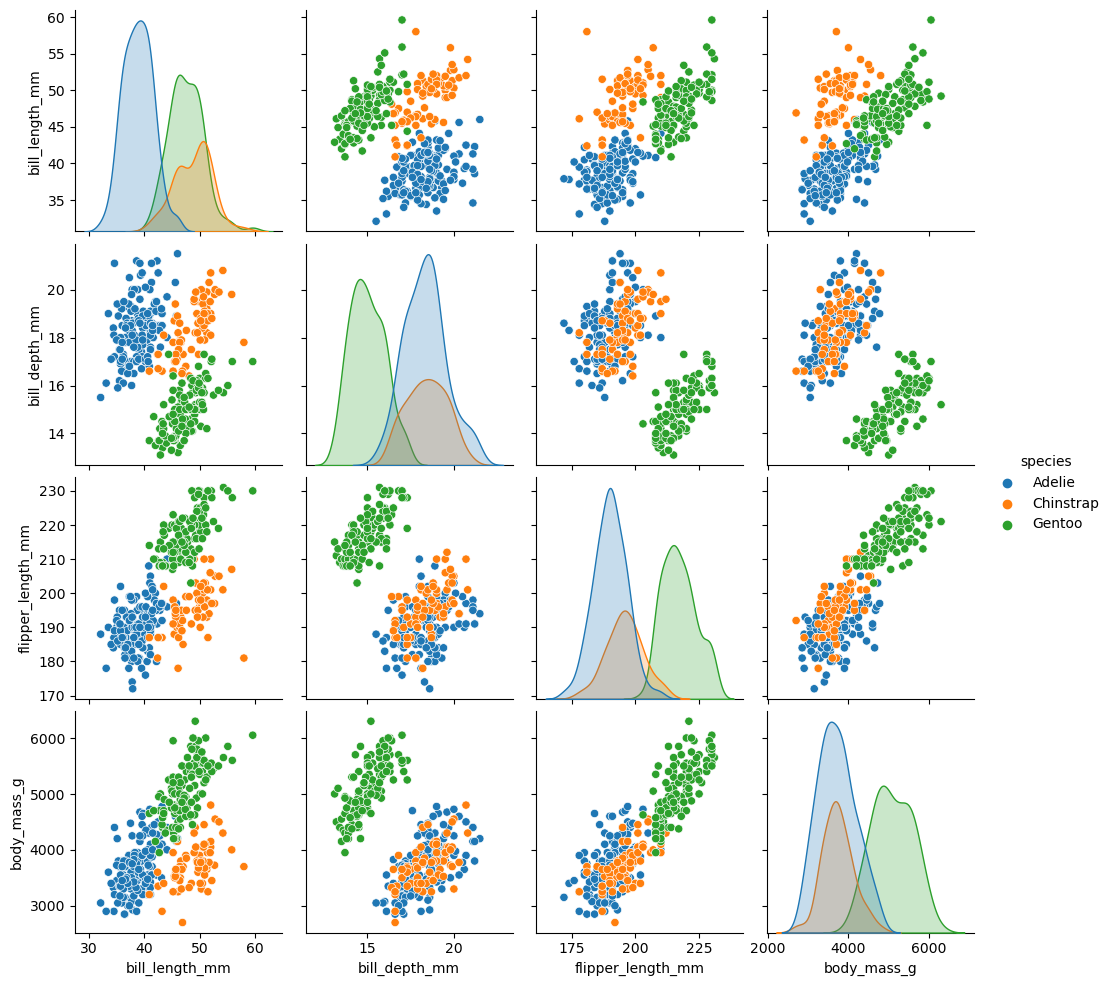

In [48]:
sns.pairplot(pg,hue='species')